# Final Evaluation of Synthetic Data

## Introduction

In this notebook, the evaluation of the synthetic datasets is carried out through three main steps. First, we load and preprocess both the original and synthetic datasets to ensure consistency and comparability. Next, we assess the predictive performance of the synthetic data by training three predictive models—logistic regression, decision tree, and random forest—and computing the mean and standard deviation of accuracy over multiple seeds. Then, a discriminator analysis is performed using a random forest to estimate how easily synthetic records can be distinguished from real ones. Finally, we calculate the Distance to Closest Record (DCR), which quantifies the similarity of each synthetic entry to its nearest counterpart in the original dataset. Each step provides complementary insights into the quality, realism, and utility of the generated data.

## 0 Imports

We import the necessary libraries for data handling, preprocessing, evaluation, and visualization. This includes pandas and numpy for data manipulation, scikit-learn for preprocessing, predictive modeling, and nearest-neighbor computations, matplotlib for plotting, and standard Python typing utilities for code clarity.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from typing import Dict, List

## Functions definitions:

The preprocess_dataset function is designed to prepare a tabular dataset for predictive evaluation. Its main steps are:

Type conversion - categorical features are explicitly converted to strings, while numerical features are coerced to numeric types to ensure consistent data handling.

Separation of features and target - the target column is separated from the input features.

Preprocessing pipeline - a ColumnTransformer is defined to handle different types of features:

Categorical features are imputed with the value "Unknown" for missing entries and one-hot encoded.

Numerical features are imputed using the mean of each column and standardized via StandardScaler.

Transformation - the input features are transformed using the pipeline.

The function returns the transformed feature matrix (X_transformed), the target vector (y), and the fitted preprocessor pipeline, which can be reused for consistent preprocessing on new data.

In [ ]:
def preprocess_dataset(df, target_column, categorical_features, numerical_features):
    for col in categorical_features:
        df[col] = df[col].astype(str)  #force categorical as string

    for col in numerical_features:
        df[col] = pd.to_numeric(df[col], errors='coerce')  #ensure float

    X = df.drop(target_column, axis=1)
    y = df[target_column]

    preprocessor = ColumnTransformer(
        transformers=[
            ('categorical', Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
                ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ]), categorical_features),

            ('numerical', Pipeline([
                ('imputer', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler())
            ]), numerical_features)
        ])

    X_transformed = preprocessor.fit_transform(X)

    return X_transformed, y, preprocessor

These three functions—train_and_evaluate_logistic_regression, train_and_evaluate_decision_tree, and train_and_evaluate_random_forest—are designed to evaluate predictive performance on a given dataset. Each function follows the same general procedure:

Data splitting - the input features (X) and target (y) are split into training and testing sets using an 80/20 split, with a fixed seed to ensure reproducibility.

Model instantiation and training - a predictive model is created (logistic regression, decision tree, or random forest) and trained on the training set.

Prediction and evaluation - the trained model predicts labels on the test set, and the accuracy score is computed as the proportion of correct predictions.

Each function returns the accuracy of the model on the test set, providing a simple metric to compare predictive performance across synthetic and original datasets.

In [ ]:
def train_and_evaluate_logistic_regression(X, y, seed):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
  log_reg = LogisticRegression(random_state=seed, max_iter=1000)
  log_reg.fit(X_train, y_train)
  y_pred = log_reg.predict(X_test)

  return accuracy_score(y_test, y_pred)

In [ ]:
def train_and_evaluate_decision_tree(X, y, seed):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
  dt = DecisionTreeClassifier(random_state=seed)
  dt.fit(X_train, y_train)
  y_pred = dt.predict(X_test)
  return accuracy_score(y_test, y_pred)

In [ ]:
def train_and_evaluate_random_forest(X, y, seed):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
  rf = RandomForestClassifier(random_state=seed)
  rf.fit(X_train, y_train)
  y_pred = rf.predict(X_test)
  return accuracy_score(y_test, y_pred)

The create_results_table function is designed to summarize evaluation results in a clear and concise format. It takes a dictionary where keys represent model names or experiment identifiers and values are lists of numerical results (e.g., accuracy scores across multiple seeds). For each entry, the function computes the mean and standard deviation and formats them as "mean ± std". If no results are available for a given key, it returns "N/A". The output is a dictionary summarizing all entries, which can be easily converted to a pandas DataFrame for reporting or visualization.

In [ ]:
def create_results_table(results_dict: Dict[str, List[float]]) -> pd.DataFrame:
    summary_stats = {}
    for key, values in results_dict.items():
        if len(values) > 0:
            mean_val = np.mean(values)
            std_val = np.std(values, ddof=1) if len(values) > 1 else 0
            summary_stats[key] = f"{mean_val:.4f} ± {std_val:.4f}"
        else:
            summary_stats[key] = "N/A"

    return summary_stats

The organize_results_for_table function aggregates and formats the evaluation results of predictive models across both the German Credit Risk and Australian Credit Approval datasets. For each dataset, it considers three predictive models—logistic regression, decision tree, and random forest—and six data sources: the original data and the synthetic data generated by CopulaGAN, TVAE, CTGAN, Distil-GReaT, and GReaT.

The function performs the following steps:

Computes the mean and standard deviation for each list of accuracy results across multiple seeds, formatting them as "mean ± std"; if no results are available, "N/A" is returned.

Organizes the results into a structured table with a multi-level index, where the first level corresponds to the dataset and the second to the predictive model.

Assigns the data sources (original and synthetic generators) as column headers.

The output is a pandas DataFrame providing a clear summary of predictive performance across datasets, models, and generative approaches, ready for reporting or visualization.

Additionally, two utility functions are provided for working with this results table:

display_formatted_table(df) prints the DataFrame in a readable, clearly formatted layout with separators and a descriptive header.

save_results_table(df, filename) exports the DataFrame to a CSV file for external use or record keeping, providing feedback on the saved file location.

Together, these functions streamline the presentation, inspection, and storage of evaluation results.

In [ ]:
def organize_results_for_table(
    #German Credit results
    lr_german_original_results, lr_german_CopulaGAN_results, lr_german_TVAE_results,
    lr_german_CTGAN_results, lr_german_distil_GReaT_results, lr_german_GReaT_results,
    dt_german_original_results, dt_german_CopulaGAN_results, dt_german_TVAE_results,
    dt_german_CTGAN_results, dt_german_distil_GReaT_results, dt_german_GReaT_results,
    rf_german_original_results, rf_german_CopulaGAN_results, rf_german_TVAE_results,
    rf_german_CTGAN_results, rf_german_distil_GReaT_results, rf_german_GReaT_results,

    #Australian Credit results
    lr_australian_original_results, lr_australian_CopulaGAN_results, lr_australian_TVAE_results,
    lr_australian_CTGAN_results, lr_australian_distil_GReaT_results, lr_australian_GReaT_results,
    dt_australian_original_results, dt_australian_CopulaGAN_results, dt_australian_TVAE_results,
    dt_australian_CTGAN_results, dt_australian_distil_GReaT_results, dt_australian_GReaT_results,
    rf_australian_original_results, rf_australian_CopulaGAN_results, rf_australian_TVAE_results,
    rf_australian_CTGAN_results, rf_australian_distil_GReaT_results, rf_australian_GReaT_results,

) -> pd.DataFrame:

    def calc_mean_std(values):
        if len(values) > 0:
            mean_val = np.mean(values)
            std_val = np.std(values, ddof=1) if len(values) > 1 else 0
            return f"{mean_val:.4f} ± {std_val:.4f}"
        return "N/A"

    datasets = [
        ('German Credit', [
            ('Logistic Regression', [lr_german_original_results, lr_german_CopulaGAN_results,
                                   lr_german_TVAE_results, lr_german_CTGAN_results,
                                   lr_german_distil_GReaT_results, lr_german_GReaT_results]),
            ('Decision Tree', [dt_german_original_results, dt_german_CopulaGAN_results,
                             dt_german_TVAE_results, dt_german_CTGAN_results,
                             dt_german_distil_GReaT_results, dt_german_GReaT_results]),
            ('Random Forest', [rf_german_original_results, rf_german_CopulaGAN_results,
                             rf_german_TVAE_results, rf_german_CTGAN_results,
                             rf_german_distil_GReaT_results, rf_german_GReaT_results])
        ]),

        ('Australian Credit', [
            ('Logistic Regression', [lr_australian_original_results, lr_australian_CopulaGAN_results,
                                   lr_australian_TVAE_results, lr_australian_CTGAN_results,
                                   lr_australian_distil_GReaT_results, lr_australian_GReaT_results]),
            ('Decision Tree', [dt_australian_original_results, dt_australian_CopulaGAN_results,
                             dt_australian_TVAE_results, dt_australian_CTGAN_results,
                             dt_australian_distil_GReaT_results, dt_australian_GReaT_results]),
            ('Random Forest', [rf_australian_original_results, rf_australian_CopulaGAN_results,
                            rf_australian_TVAE_results, rf_australian_CTGAN_results,
                             rf_australian_distil_GReaT_results, rf_australian_GReaT_results])
        ])
    ]

    generator_names = ['Original', 'CopulaGAN', 'TVAE', 'CTGAN', 'Distil-GReaT', 'GReaT']

    rows = []
    index_tuples = []

    for dataset_name, models in datasets:
        for model_name, results_lists in models:
            row = []
            for results_list in results_lists:
                row.append(calc_mean_std(results_list))
            rows.append(row)
            index_tuples.append((dataset_name, model_name))

    multi_index = pd.MultiIndex.from_tuples(index_tuples, names=['Dataset', 'Model'])
    df = pd.DataFrame(rows, index=multi_index, columns=generator_names)

    return df

In [ ]:
def display_formatted_table(df: pd.DataFrame):
    print("=== RESULTS TABLE: ACCURACY (Mean ± Std) ===")
    print("=" * 100)
    print(df.to_string())
    print("=" * 100)

    return df

In [ ]:
def save_results_table(df: pd.DataFrame, filename: str = "results_table.csv"):
    df.to_csv(filename)
    print(f"Table saved in: {filename}")

The organize_discriminator_results_for_table function formats the results of the discriminator analysis, which measures how well a random forest can distinguish synthetic records from original ones. The function considers both the German Credit Risk and Australian Credit Approval datasets, and for each dataset it evaluates the synthetic data generated by five models: CopulaGAN, TVAE, CTGAN, Distil-GReaT, and GReaT.

The procedure is as follows:

For each generator, the function calculates the mean and standard deviation of the discriminator accuracy across multiple seeds, formatting them as "mean ± std"; if no results are available, "N/A" is returned.

Results are organized into a multi-index DataFrame, with datasets as the first index level and "Discriminator" as the second, while the generators form the columns.

The resulting DataFrame provides a clear summary of discriminator performance, facilitating comparison of how distinguishable synthetic data is across different generative models and datasets.

In [ ]:
def organize_discriminator_results_for_table(
    #German Credit
    german_CopulaGAN_discriminator_results, german_TVAE_discriminator_results,
    german_CTGAN_discriminator_results, german_distil_GReaT_discriminator_results,
    german_GReaT_discriminator_results,

    #Australian Credit
    australian_CopulaGAN_discriminator_results, australian_TVAE_discriminator_results,
    australian_CTGAN_discriminator_results, australian_distil_GReaT_discriminator_results,
    australian_GReaT_discriminator_results,
) -> pd.DataFrame:

    def calc_mean_std(values):
        if len(values) > 0:
            mean_val = np.mean(values)
            std_val = np.std(values, ddof=1) if len(values) > 1 else 0
            return f"{mean_val:.4f} ± {std_val:.4f}"
        return "N/A"


    datasets = [
        ('German Credit', [
            ('Discriminator', [german_CopulaGAN_discriminator_results, german_TVAE_discriminator_results,
                              german_CTGAN_discriminator_results, german_distil_GReaT_discriminator_results,
                              german_GReaT_discriminator_results,])
        ]),
        ('Australian Credit', [
            ('Discriminator', [australian_CopulaGAN_discriminator_results, australian_TVAE_discriminator_results,
                              australian_CTGAN_discriminator_results, australian_distil_GReaT_discriminator_results,
                              australian_GReaT_discriminator_results])
        ])
    ]

    generator_names = ['CopulaGAN', 'TVAE', 'CTGAN', 'Distil-GReaT', 'GReaT']


    rows = []
    index_tuples = []

    for dataset_name, models in datasets:
        for model_name, results_lists in models:
            row = [calc_mean_std(results) for results in results_lists]
            rows.append(row)
            index_tuples.append((dataset_name, model_name))

    multi_index = pd.MultiIndex.from_tuples(index_tuples, names=['Dataset', 'Model'])
    df = pd.DataFrame(rows, index=multi_index, columns=generator_names)

    return df

The compute_dcr function calculates the Distance to Closest Record (DCR) between a synthetic dataset and its corresponding real dataset. Using a nearest neighbors approach with Euclidean distance, the function finds, for each synthetic record, the closest record in the original dataset and computes the distance. The output is a one-dimensional array of distances, providing a quantitative measure of similarity between synthetic and real records.

In [ ]:
def compute_dcr(real_data, synthetic_data):
    #Compute Distance to Closest Record (DCR) values
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(real_data)
    distances, _ = nn.kneighbors(synthetic_data)
    return distances.flatten()

## 1 Dataset loading

In this section, we load all relevant datasets from CSV files and convert them into pandas DataFrames for further analysis. Both the original datasets (German Credit Risk and Australian Credit Approval) and the synthetic datasets generated by the different models are loaded.

Additionally, we define the categorical and numerical features for each dataset, which will be used in the preprocessing steps to ensure consistent data types and transformations for evaluation purposes.

#### German Credist Risk

In [ ]:
#Load German Credit Risk
german_df = pd.read_csv('german_credit_risk.csv')

In [ ]:
german_df = german_df.drop(german_df.columns[0], axis=1)

german_categorical_features = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
german_numerical_features = ['Age', 'Credit amount', 'Duration']

In [ ]:
synthetic_german_df_CopulaGan = pd.read_csv('synthetic_data_german_CopulaGAN.csv')
synthetic_german_df_TVAE = pd.read_csv('synthetic_data_german_TVAE.csv')
synthetic_german_df_CTGAN = pd.read_csv('synthetic_data_german_CTGAN.csv')
synthetic_german_df_distil_GReaT = pd.read_csv('synthetic_data_german_distil_GReaT.csv')
synthetic_german_df_GReaT = pd.read_csv('synthetic_data_german_GReaT.csv')

#### Australian Credit Approval

In [ ]:
#Load Australian Credit Approval
column_names = [
    "A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9",
    "A10", "A11", "A12", "A13", "A14", "A15"
]

#Load dataset without using the first row as header
australian_df = pd.read_csv("australian.csv", names=column_names, header=None)

In [ ]:
#Ensuring target labels are integers (for classification)
australian_df['A15'] = australian_df['A15'].round().astype(int)

In [ ]:
australian_categorical_features = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']
australian_numerical_features = ['A2', 'A3', 'A7', 'A10', 'A13', 'A14']

In [ ]:
synthetic_australian_df_CopulaGan = pd.read_csv('synthetic_data_australian_CopulaGAN.csv')
synthetic_australian_df_TVAE = pd.read_csv('synthetic_data_australian_TVAE.csv')
synthetic_australian_df_CTGAN = pd.read_csv('synthetic_data_australian_CTGAN.csv')
synthetic_australian_df_distil_GReaT = pd.read_csv('synthetic_data_australian_distil_GReaT.csv')
synthetic_australian_df_GReaT = pd.read_csv('synthetic_data_australian_GReaT.csv')

## 2 Preprocessing

In this phase, we preprocess both the original and synthetic datasets using the previously defined preprocess_dataset function. This step ensures that categorical and numerical features are correctly encoded and scaled, and that missing values are appropriately handled. The output consists of the transformed feature matrices, the target vectors, and the fitted preprocessing pipelines, which will be consistently used for all subsequent predictive evaluations.

### German

In [ ]:
X_german, y_german, preprocessor = preprocess_dataset(german_df, 'Risk', german_categorical_features, german_numerical_features)

In [ ]:
X_german_CopulaGAN, y_german_CopulaGAN, preprocessor = preprocess_dataset(synthetic_german_df_CopulaGan, 'Risk', german_categorical_features, german_numerical_features)

In [ ]:
X_german_TVAE, y_german_TVAE, preprocessor = preprocess_dataset(synthetic_german_df_TVAE, 'Risk', german_categorical_features, german_numerical_features)

In [ ]:
X_german_CTGAN, y_german_CTGAN, preprocessor = preprocess_dataset(synthetic_german_df_CTGAN, 'Risk', german_categorical_features, german_numerical_features)

In [ ]:
X_german_distil_GReaT, y_german_distil_GReaT, preprocessor = preprocess_dataset(synthetic_german_df_distil_GReaT, 'Risk', german_categorical_features, german_numerical_features)

In [ ]:
X_german_GReaT, y_german_GReaT, preprocessor = preprocess_dataset(synthetic_german_df_GReaT, 'Risk', german_categorical_features, german_numerical_features)

### Australian

In [ ]:
australian_df.rename(columns={"A15": "Class"}, inplace=True)

In [ ]:
X_australian, y_australian, preprocessor = preprocess_dataset(australian_df,'Class', australian_numerical_features, australian_categorical_features)

In [ ]:
X_australian_CopulaGAN, y_australian_CopulaGAN, preprocessor = preprocess_dataset(synthetic_australian_df_CopulaGan,'Class', australian_numerical_features, australian_categorical_features)

In [ ]:
X_australian_TVAE, y_australian_TVAE, preprocessor = preprocess_dataset(synthetic_australian_df_TVAE,'Class', australian_numerical_features, australian_categorical_features)

In [ ]:
X_australian_CTGAN, y_australian_CTGAN, preprocessor = preprocess_dataset(synthetic_australian_df_CTGAN,'Class', australian_numerical_features, australian_categorical_features)

In [ ]:
X_australian_distil_GReaT, y_australian_distil_GReaT, preprocessor = preprocess_dataset(synthetic_australian_df_distil_GReaT,'Class', australian_numerical_features, australian_categorical_features)

In [ ]:
X_australian_GReaT, y_australian_GReaT, preprocessor = preprocess_dataset(synthetic_australian_df_GReaT,'Class', australian_numerical_features, australian_categorical_features)

## 3 Evaluation

In this section, we perform predictive evaluation of the synthetic datasets. First, we initialize the necessary variables to store results and define the random seeds for reproducibility. We then train and evaluate three predictive models—logistic regression, decision tree, and random forest—on both the original and synthetic datasets. Finally, the results from all models and datasets are collected and summarized in a structured table, providing a comprehensive overview of predictive performance for subsequent analysis.

### Initialization

In [ ]:
#We consider five different seeds
RANDOM_SEEDS = [42, 43, 44, 45, 46]

In [ ]:
lr_german_original_results = []
lr_german_CopulaGAN_results = []
lr_german_TVAE_results = []
lr_german_CTGAN_results = []
lr_german_distil_GReaT_results = []
lr_german_GReaT_results = []
dt_german_original_results = []
dt_german_CopulaGAN_results = []
dt_german_TVAE_results = []
dt_german_CTGAN_results = []
dt_german_distil_GReaT_results = []
dt_german_GReaT_results = []
rf_german_original_results = []
rf_german_CopulaGAN_results = []
rf_german_TVAE_results = []
rf_german_CTGAN_results = []
rf_german_distil_GReaT_results = []
rf_german_GReaT_results = []

In [ ]:
lr_australian_original_results = []
lr_australian_CopulaGAN_results = []
lr_australian_TVAE_results = []
lr_australian_CTGAN_results = []
lr_australian_distil_GReaT_results = []
lr_australian_GReaT_results = []
dt_australian_original_results = []
dt_australian_CopulaGAN_results = []
dt_australian_TVAE_results = []
dt_australian_CTGAN_results = []
dt_australian_distil_GReaT_results = []
dt_australian_GReaT_results = []
rf_australian_original_results = []
rf_australian_CopulaGAN_results = []
rf_australian_TVAE_results = []
rf_australian_CTGAN_results = []
rf_australian_distil_GReaT_results = []
rf_australian_GReaT_results = []

### Logistic Regression

Now we start computing the classifiers' results for each dataset.

#### Original datasets

In [ ]:
for seed in RANDOM_SEEDS:
  lr_german_original_results.append(train_and_evaluate_logistic_regression(X_german, y_german, seed))
  lr_australian_original_results.append(train_and_evaluate_logistic_regression(X_australian, y_australian, seed))

#### CopulaGAN datasets

In [ ]:
for seed in RANDOM_SEEDS:
  lr_german_CopulaGAN_results.append(train_and_evaluate_logistic_regression(X_german_CopulaGAN, y_german_CopulaGAN, seed))
  lr_australian_CopulaGAN_results.append(train_and_evaluate_logistic_regression(X_australian_CopulaGAN, y_australian_CopulaGAN, seed))

#### TVAE datasets

In [ ]:
for seed in RANDOM_SEEDS:
  lr_german_TVAE_results.append(train_and_evaluate_logistic_regression(X_german_TVAE, y_german_TVAE, seed))
  lr_australian_TVAE_results.append(train_and_evaluate_logistic_regression(X_australian_TVAE, y_australian_TVAE, seed))

#### CTGAN datasets

In [ ]:
for seed in RANDOM_SEEDS:
  lr_german_CTGAN_results.append(train_and_evaluate_logistic_regression(X_german_CTGAN, y_german_CTGAN, seed))
  lr_australian_CTGAN_results.append(train_and_evaluate_logistic_regression(X_australian_CTGAN, y_australian_CTGAN, seed))

#### Distil-GReaT datasets

In [ ]:
for seed in RANDOM_SEEDS:
  lr_german_distil_GReaT_results.append(train_and_evaluate_logistic_regression(X_german_distil_GReaT, y_german_distil_GReaT, seed))
  lr_australian_distil_GReaT_results.append(train_and_evaluate_logistic_regression(X_australian_distil_GReaT, y_australian_distil_GReaT, seed))

#### GReaT datasets

In [ ]:
for seed in RANDOM_SEEDS:
  lr_german_GReaT_results.append(train_and_evaluate_logistic_regression(X_german_GReaT, y_german_GReaT, seed))
  lr_australian_GReaT_results.append(train_and_evaluate_logistic_regression(X_australian_GReaT, y_australian_GReaT, seed))

### Decision Tree

#### Original dataset

In [ ]:
for seed in RANDOM_SEEDS:
    dt_german_original_results.append(train_and_evaluate_decision_tree(X_german, y_german, seed))
    dt_australian_original_results.append(train_and_evaluate_decision_tree(X_australian, y_australian, seed))

#### CopulaGAN datasets

In [ ]:
for seed in RANDOM_SEEDS:
  dt_german_CopulaGAN_results.append(train_and_evaluate_decision_tree(X_german_CopulaGAN, y_german_CopulaGAN, seed))
  dt_australian_CopulaGAN_results.append(train_and_evaluate_decision_tree(X_australian_CopulaGAN, y_australian_CopulaGAN, seed))

#### TVAE datasets

In [ ]:
for seed in RANDOM_SEEDS:
  dt_german_TVAE_results.append(train_and_evaluate_decision_tree(X_german_TVAE, y_german_TVAE, seed))
  dt_australian_TVAE_results.append(train_and_evaluate_decision_tree(X_australian_TVAE, y_australian_TVAE, seed))

#### CTGAN datasets

In [ ]:
for seed in RANDOM_SEEDS:
  dt_german_CTGAN_results.append(train_and_evaluate_decision_tree(X_german_CTGAN, y_german_CTGAN, seed))
  dt_australian_CTGAN_results.append(train_and_evaluate_decision_tree(X_australian_CTGAN, y_australian_CTGAN, seed))

#### Distil-GReaT datasets

In [ ]:
for seed in RANDOM_SEEDS:
  dt_german_distil_GReaT_results.append(train_and_evaluate_decision_tree(X_german_distil_GReaT, y_german_distil_GReaT, seed))
  dt_australian_distil_GReaT_results.append(train_and_evaluate_decision_tree(X_australian_distil_GReaT, y_australian_distil_GReaT, seed))

#### GReaT datasets

In [ ]:
for seed in RANDOM_SEEDS:
  dt_german_GReaT_results.append(train_and_evaluate_decision_tree(X_german_GReaT, y_german_GReaT, seed))
  dt_australian_GReaT_results.append(train_and_evaluate_decision_tree(X_australian_GReaT, y_australian_GReaT, seed))

### Random Forest

#### Original datasets

In [ ]:
for seed in RANDOM_SEEDS:
  rf_german_original_results.append(train_and_evaluate_random_forest(X_german, y_german, seed))
  rf_australian_original_results.append(train_and_evaluate_random_forest(X_australian, y_australian, seed))

#### CopulaGAN datasets

In [ ]:
for seed in RANDOM_SEEDS:
  rf_german_CopulaGAN_results.append(train_and_evaluate_random_forest(X_german_CopulaGAN, y_german_CopulaGAN, seed))
  rf_australian_CopulaGAN_results.append(train_and_evaluate_random_forest(X_australian_CopulaGAN, y_australian_CopulaGAN, seed))

#### TVAE datasets

In [ ]:
for seed in RANDOM_SEEDS:
  rf_german_TVAE_results.append(train_and_evaluate_random_forest(X_german_TVAE, y_german_TVAE, seed))
  rf_australian_TVAE_results.append(train_and_evaluate_random_forest(X_australian_TVAE, y_australian_TVAE, seed))

#### CTGAN datasets

In [ ]:
for seed in RANDOM_SEEDS:
  rf_german_CTGAN_results.append(train_and_evaluate_random_forest(X_german_CTGAN, y_german_CTGAN, seed))
  rf_australian_CTGAN_results.append(train_and_evaluate_random_forest(X_australian_CTGAN, y_australian_CTGAN, seed))

#### Distil-GReaT datasets

In [ ]:
for seed in RANDOM_SEEDS:
  rf_german_distil_GReaT_results.append(train_and_evaluate_random_forest(X_german_distil_GReaT, y_german_distil_GReaT, seed))
  rf_australian_distil_GReaT_results.append(train_and_evaluate_random_forest(X_australian_distil_GReaT, y_australian_distil_GReaT, seed))

#### GReaT datasets

In [ ]:
for seed in RANDOM_SEEDS:
  rf_german_GReaT_results.append(train_and_evaluate_random_forest(X_german_GReaT, y_german_GReaT, seed))
  rf_australian_GReaT_results.append(train_and_evaluate_random_forest(X_australian_GReaT, y_australian_GReaT, seed))

### Results

At this stage, we organize the collected results into a structured table that summarizes the predictive performance across datasets, models, and generators. The table is then displayed in a readable format and also saved as a CSV file for future reference and analysis.

In [ ]:
results_table = organize_results_for_table(
    #German Credit results
    lr_german_original_results, lr_german_CopulaGAN_results, lr_german_TVAE_results,
    lr_german_CTGAN_results, lr_german_distil_GReaT_results, lr_german_GReaT_results,
    dt_german_original_results, dt_german_CopulaGAN_results, dt_german_TVAE_results,
    dt_german_CTGAN_results, dt_german_distil_GReaT_results, dt_german_GReaT_results,
    rf_german_original_results, rf_german_CopulaGAN_results, rf_german_TVAE_results,
    rf_german_CTGAN_results, rf_german_distil_GReaT_results, rf_german_GReaT_results,

    #Australian Credit results
    lr_australian_original_results, lr_australian_CopulaGAN_results, lr_australian_TVAE_results,
    lr_australian_CTGAN_results, lr_australian_distil_GReaT_results, lr_australian_GReaT_results,
    dt_australian_original_results, dt_australian_CopulaGAN_results, dt_australian_TVAE_results,
    dt_australian_CTGAN_results, dt_australian_distil_GReaT_results, dt_australian_GReaT_results,
    rf_australian_original_results, rf_australian_CopulaGAN_results, rf_australian_TVAE_results,
    rf_australian_CTGAN_results, rf_australian_distil_GReaT_results, rf_australian_GReaT_results,
)

display_formatted_table(results_table)

save_results_table(results_table, "synthetic_data_results.csv")

display(results_table)

=== RESULTS TABLE: ACCURACY (Mean ± Std) ===
                                              Original        CopulaGAN             TVAE            CTGAN     Distil-GReaT            GReaT
Dataset           Model                                                                                                                    
German Credit     Logistic Regression  0.7390 ± 0.0185  0.5440 ± 0.0216  0.8740 ± 0.0096  0.7960 ± 0.0248  0.6670 ± 0.0299  0.8060 ± 0.0309
                  Decision Tree        0.6610 ± 0.0185  0.4980 ± 0.0220  0.8500 ± 0.0427  0.6870 ± 0.0192  0.5390 ± 0.0152  0.6800 ± 0.0314
                  Random Forest        0.7520 ± 0.0233  0.5230 ± 0.0478  0.8620 ± 0.0179  0.7870 ± 0.0164  0.6410 ± 0.0366  0.8000 ± 0.0302
Australian Credit Logistic Regression  0.8522 ± 0.0121  0.5391 ± 0.0412  0.8986 ± 0.0271  0.4928 ± 0.0154  0.8884 ± 0.0189  0.8681 ± 0.0313
                  Decision Tree        0.8188 ± 0.0266  0.4768 ± 0.0338  0.8783 ± 0.0188  0.5087 ± 0.0626  0.8333 ±

Original        CopulaGAN  \
Dataset           Model                                                   
German Credit     Logistic Regression  0.7390 ± 0.0185  0.5440 ± 0.0216   
                  Decision Tree        0.6610 ± 0.0185  0.4980 ± 0.0220   
                  Random Forest        0.7520 ± 0.0233  0.5230 ± 0.0478   
Australian Credit Logistic Regression  0.8522 ± 0.0121  0.5391 ± 0.0412   
                  Decision Tree        0.8188 ± 0.0266  0.4768 ± 0.0338   
                  Random Forest        0.8580 ± 0.0259  0.5319 ± 0.0233   

                                                  TVAE            CTGAN  \
Dataset           Model                                                   
German Credit     Logistic Regression  0.8740 ± 0.0096  0.7960 ± 0.0248   
                  Decision Tree        0.8500 ± 0.0427  0.6870 ± 0.0192   
                  Random Forest        0.8620 ± 0.0179  0.7870 ± 0.0164   
Australian Credit Logistic Regression  0.8986 ± 0.0271  0.4928 ± 0.0154   
                  Decision Tree        0.8783 ± 0.0188  0.5087 ± 0.0626   
                  Random Forest        0.8870 ± 0.0283  0.4565 ± 0.0136   

                                          Distil-GReaT            GReaT  
Dataset           Model                                                  
German Credit     Logistic Regression  0.6670 ± 0.0299  0.8060 ± 0.0309  
                  Decision Tree        0.5390 ± 0.0152  0.6800 ± 0.0314  
                  Random Forest        0.6410 ± 0.0366  0.8000 ± 0.0302  
Australian Credit Logistic Regression  0.8884 ± 0.0189  0.8681 ± 0.0313  
                  Decision Tree        0.8333 ± 0.0211  0.8246 ± 0.0408  
                  Random Forest        0.8884 ± 0.0244  0.8754 ± 0.0309

On the German Credit dataset, the best performing model is TVAE, which consistently achieves the highest accuracies across all classifiers (87.4% with Logistic Regression, 85.0% with Decision Tree, and 86.2% with Random Forest). GReaT ranks second, with slightly lower but still competitive results, while CopulaGAN and Distil-GReaT clearly underperform, often dropping well below the baseline provided by the original dataset.

For the Australian Credit dataset, TVAE again stands out in Logistic Regression (89.9%) and Decision Tree (87.8%), whereas Distil-GReaT achieves the highest score with Random Forest (88.8%). Both GReaT and Distil-GReaT remain close to TVAE’s performance, while CopulaGAN and CTGAN show significant weaknesses, with accuracies in some cases falling below 50%.

Overall, TVAE appears to be the most reliable model across both datasets, showing stable and high performance. However, GReaT demonstrates a notable strength on datasets with predominantly numerical features (such as the Australian Credit dataset, where categorical features are already encoded). In such contexts, GReaT can even surpass the accuracy obtained on the original data. This contrasts with its performance on the German dataset, where some categorical columns led to concatenations of out-of-context text fragments during generation — an artifact we previously identified as a limitation of LLM-based approaches like GReaT.

## 4 Discriminator

In this section we evaluate the ability of a discriminator to distinguish between real and synthetic data. For each dataset (German and Australian Credit), we combine the original records with those generated by different models, assigning labels to mark real (0) versus synthetic (1). These prepared datasets are then used to assess how well the discriminator can separate authentic data from generated samples.

In [ ]:
german_CopulaGAN_discriminator_results = []
australian_CopulaGAN_discriminator_results = []

german_TVAE_discriminator_results = []
australian_TVAE_discriminator_results = []

german_CTGAN_discriminator_results = []
australian_CTGAN_discriminator_results = []

german_distil_GReaT_discriminator_results = []
australian_distil_GReaT_discriminator_results = []

german_GReaT_discriminator_results = []
australian_GReaT_discriminator_results = []

german_df_copy = german_df.copy()
australian_df_copy = australian_df.copy()

german_df_copy['Label'] = 0
australian_df_copy['Label'] = 0

synthetic_german_df_CopulaGan['Label'] = 1
synthetic_australian_df_CopulaGan['Label'] = 1

synthetic_german_df_TVAE['Label'] = 1
synthetic_australian_df_TVAE['Label'] = 1

synthetic_german_df_CTGAN['Label'] = 1
synthetic_australian_df_CTGAN['Label'] = 1

synthetic_german_df_distil_GReaT['Label'] = 1
synthetic_australian_df_distil_GReaT['Label'] = 1

synthetic_german_df_GReaT['Label'] = 1
synthetic_australian_df_GReaT['Label'] = 1

### Combinations of the datasets

In this step we build combined datasets by merging the original records with their corresponding synthetic counterparts for both German and Australian Credit. This creates a unified view that will be later used by the discriminator to distinguish between real and generated data. Additionally, the target columns (Risk for German and Class for Australian) are appended to the list of categorical features, ensuring that they are consistently handled during preprocessing.

In [ ]:
german_CopulaGAN_combined_df = pd.concat([german_df_copy, synthetic_german_df_CopulaGan])
australian_CopulaGAN_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_CopulaGan])

german_TVAE_combined_df = pd.concat([german_df_copy, synthetic_german_df_TVAE])
australian_TVAE_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_TVAE])

german_CTGAN_combined_df = pd.concat([german_df_copy, synthetic_german_df_CTGAN])
australian_CTGAN_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_CTGAN])

german_distil_GReaT_combined_df = pd.concat([german_df_copy, synthetic_german_df_distil_GReaT])
australian_distil_GReaT_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_distil_GReaT])

german_GReaT_combined_df = pd.concat([german_df_copy, synthetic_german_df_GReaT])
australian_GReaT_combined_df = pd.concat([australian_df_copy, synthetic_australian_df_GReaT])

german_categorical_features.append('Risk')
australian_categorical_features.append('Class')

### Preprocessing

The combined datasets are preprocessed using the same pipeline defined earlier, ensuring consistent handling of categorical and numerical features before training the discriminator.

####CopulaGAN

In [ ]:
X_german_CopulaGAN_combined, y_german_CopulaGAN_combined, german_preprocessor = preprocess_dataset(german_CopulaGAN_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_CopulaGAN_combined, y_australian_CopulaGAN_combined, australian_preprocessor = preprocess_dataset(australian_CopulaGAN_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

#### TVAE

In [ ]:
X_german_TVAE_combined, y_german_TVAE_combined, german_preprocessor = preprocess_dataset(german_TVAE_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_TVAE_combined, y_australian_TVAE_combined, australian_preprocessor = preprocess_dataset(australian_TVAE_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

#### CTGAN

In [ ]:
X_german_CTGAN_combined, y_german_CTGAN_combined, german_preprocessor = preprocess_dataset(german_CTGAN_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_CTGAN_combined, y_australian_CTGAN_combined, australian_preprocessor = preprocess_dataset(australian_CTGAN_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

#### Distil-GReaT

In [ ]:
X_german_distil_GReaT_combined, y_german_distil_GReaT_combined, german_preprocessor = preprocess_dataset(german_distil_GReaT_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_distil_GReaT_combined, y_australian_distil_GReaT_combined, australian_preprocessor = preprocess_dataset(australian_distil_GReaT_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

#### GReaT

In [ ]:
X_german_GReaT_combined, y_german_GReaT_combined, german_preprocessor = preprocess_dataset(german_GReaT_combined_df, 'Label', german_categorical_features, german_numerical_features)
X_australian_GReaT_combined, y_australian_GReaT_combined, australian_preprocessor = preprocess_dataset(australian_GReaT_combined_df, 'Label', australian_categorical_features, australian_numerical_features)

### Evaluation of the discriminator

The discriminator (Random Forest) is trained and evaluated across multiple seeds, and the resulting accuracies are collected for each real–synthetic dataset pair.

#### CopulaGAN

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest(X_german_CopulaGAN_combined, y_german_CopulaGAN_combined, seed)
    german_CopulaGAN_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest(X_australian_CopulaGAN_combined, y_australian_CopulaGAN_combined, seed)
    australian_CopulaGAN_discriminator_results.append(acc)

#### TVAE

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest(X_german_TVAE_combined, y_german_TVAE_combined, seed)
    german_TVAE_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest(X_australian_TVAE_combined, y_australian_TVAE_combined, seed)
    australian_TVAE_discriminator_results.append(acc)

#### CTGAN

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest(X_german_CTGAN_combined, y_german_CTGAN_combined, seed)
    german_CTGAN_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest(X_australian_CTGAN_combined, y_australian_CTGAN_combined, seed)
    australian_CTGAN_discriminator_results.append(acc)

#### Distil-GReaT

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest(X_german_distil_GReaT_combined, y_german_distil_GReaT_combined, seed)
    german_distil_GReaT_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest(X_australian_distil_GReaT_combined, y_australian_distil_GReaT_combined, seed)
    australian_distil_GReaT_discriminator_results.append(acc)

#### GReaT

In [ ]:
for seed in RANDOM_SEEDS:
    acc = train_and_evaluate_random_forest(X_german_GReaT_combined, y_german_GReaT_combined, seed)
    german_GReaT_discriminator_results.append(acc)
    acc = train_and_evaluate_random_forest(X_australian_GReaT_combined, y_australian_GReaT_combined, seed)
    australian_GReaT_discriminator_results.append(acc)

### Discriminator's results

In this phase, the collected discriminator accuracies are organized into a structured table, displayed for inspection, and saved to a CSV file for future reference.

In [ ]:
discriminator_results_table = organize_discriminator_results_for_table(
    #German Credit discriminator's results
    german_CopulaGAN_discriminator_results, german_TVAE_discriminator_results,
    german_CTGAN_discriminator_results, german_distil_GReaT_discriminator_results,
    german_GReaT_discriminator_results,

    #Australian Credit discriminator's results
    australian_CopulaGAN_discriminator_results, australian_TVAE_discriminator_results,
    australian_CTGAN_discriminator_results, australian_distil_GReaT_discriminator_results,
    australian_GReaT_discriminator_results,
)

In [ ]:
display_formatted_table(discriminator_results_table)

save_results_table(discriminator_results_table, "discriminator_results.csv")

display(discriminator_results_table)

=== RESULTS TABLE: ACCURACY (Mean ± Std) ===
                                       CopulaGAN             TVAE            CTGAN     Distil-GReaT            GReaT
Dataset           Model                                                                                             
German Credit     Discriminator  0.9005 ± 0.0118  0.9440 ± 0.0060  0.8950 ± 0.0092  0.9995 ± 0.0011  0.8945 ± 0.0082
Australian Credit Discriminator  0.9420 ± 0.0092  0.8696 ± 0.0292  0.8783 ± 0.0091  0.7101 ± 0.0172  0.6246 ± 0.0253
Table saved in: discriminator_results.csv


,,CopulaGAN,TVAE,CTGAN,Distil-GReaT,GReaT
Dataset,Model,,,,,
German Credit,Discriminator,0.9005 ± 0.0118,0.9440 ± 0.0060,0.8950 ± 0.0092,0.9995 ± 0.0011,0.8945 ± 0.0082
Australian Credit,Discriminator,0.9420 ± 0.0092,0.8696 ± 0.0292,0.8783 ± 0.0091,0.7101 ± 0.0172,0.6246 ± 0.0253


For the German Credit dataset, the discriminator achieves very high accuracies across all models, indicating that the synthetic data is easily distinguishable from the real data. The most striking case is Distil-GReaT, which reaches an almost perfect accuracy of 99.9%, suggesting that its generated samples contain strong artifacts or distributional mismatches. The comparatively best-performing models are CTGAN (89.5%) and GReaT (89.4%), though their accuracies remain too high for the discriminator to be effectively “fooled.” Overall, these results highlight the difficulty of generating convincing categorical-heavy data, where generative models often struggle to reproduce the complex dependencies between discrete variables.

In contrast, the Australian Credit dataset yields more promising results. While CopulaGAN and CTGAN still show high discriminator accuracies (94.2% and 87.8%, respectively), Distil-GReaT drops to 71% and GReaT to 62.5%, reflecting a significant improvement in the ability of these models to produce synthetic data that more closely resembles the real distribution. This supports the observation that numerical datasets tend to be easier to model, as they avoid the combinatorial challenges and sparsity associated with categorical variables.

A possible explanation for this discrepancy lies in the data characteristics: in categorical-rich datasets like German Credit, synthetic models—particularly LLM-based approaches—may introduce artifacts such as implausible category combinations or rare-value inflation, which a discriminator can detect with ease. On numerical-dominant datasets, however, the models appear to generate more consistent samples, reducing the discriminative power of the classifier.

## 5 Distance to Closest Record (DCR)

In this section, we evaluate the Distance to Closest Record (DCR) metric to quantify how closely each synthetic sample matches its nearest counterpart in the original dataset. The workflow involves preprocessing the datasets to ensure comparable feature spaces, computing the DCR values for each synthetic dataset, and visualizing the results through summary plots to assess the fidelity of the generated data.

### Preprocessing

Both the original and synthetic datasets are preprocessed using column transformers to ensure a consistent feature representation. Categorical features are one-hot encoded, and numerical features are standardized, allowing the DCR computation to be performed reliably across all datasets.

In [ ]:
german_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), german_categorical_features),
        ('num', StandardScaler(), german_numerical_features)
    ])

X_german = german_preprocessor.fit_transform(german_df_copy)
X_german_CopulaGAN = german_preprocessor.transform(synthetic_german_df_CopulaGan)
X_german_TVAE = german_preprocessor.transform(synthetic_german_df_TVAE)
X_german_CTGAN = german_preprocessor.transform(synthetic_german_df_CTGAN)
X_german_distil_GReaT = german_preprocessor.transform(synthetic_german_df_distil_GReaT)
X_german_GReaT = german_preprocessor.transform(synthetic_german_df_GReaT)

In [ ]:
australian_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), australian_categorical_features),
        ('num', StandardScaler(), australian_numerical_features)
    ])

X_australian = australian_preprocessor.fit_transform(australian_df)
X_australian_CopulaGAN = australian_preprocessor.transform(synthetic_australian_df_CopulaGan)
X_australian_TVAE = australian_preprocessor.transform(synthetic_australian_df_TVAE)
X_australian_CTGAN = australian_preprocessor.transform(synthetic_australian_df_CTGAN)
X_australian_distil_GReaT = australian_preprocessor.transform(synthetic_australian_df_distil_GReaT)
X_australian_GReaT = australian_preprocessor.transform(synthetic_australian_df_GReaT)

### DCR Computation

The Distance to Closest Record (DCR) is computed for each synthetic dataset relative to its corresponding original dataset. The resulting distributions are then visualized with histograms to provide a clear overview of how closely the synthetic samples resemble real data in terms of feature space proximity.

#### German Credit

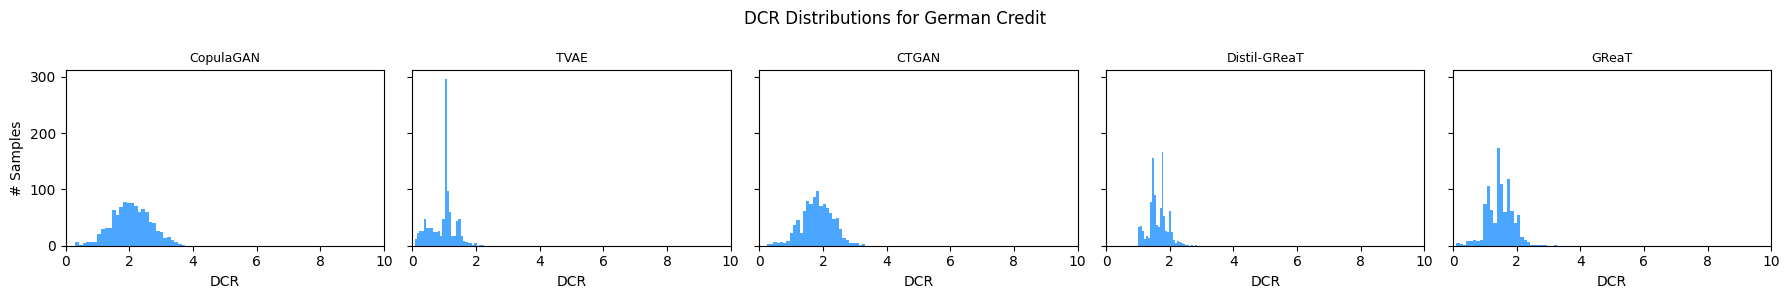

In [ ]:
#Computing DCR values for each generator
dcr_results = {
    "CopulaGAN": compute_dcr(X_german, X_german_CopulaGAN),
    "TVAE": compute_dcr(X_german, X_german_TVAE),
    "CTGAN": compute_dcr(X_german, X_german_CTGAN),
    "Distil-GReaT": compute_dcr(X_german, X_german_distil_GReaT),
    "GReaT": compute_dcr(X_german, X_german_GReaT),
}

#Histograms plotting
fig, axes = plt.subplots(1, len(dcr_results), figsize=(18, 3), sharey=True)
fig.suptitle(f"DCR Distributions for German Credit", fontsize=12)

for ax, (model_name, dcr_values) in zip(axes, dcr_results.items()):
    ax.hist(dcr_values, bins=30, color="dodgerblue", alpha=0.8)
    ax.set_title(model_name, fontsize=9)
    ax.set_xlabel("DCR")
    if ax == axes[0]:
        ax.set_ylabel("# Samples")
    ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

#### Australian Credit

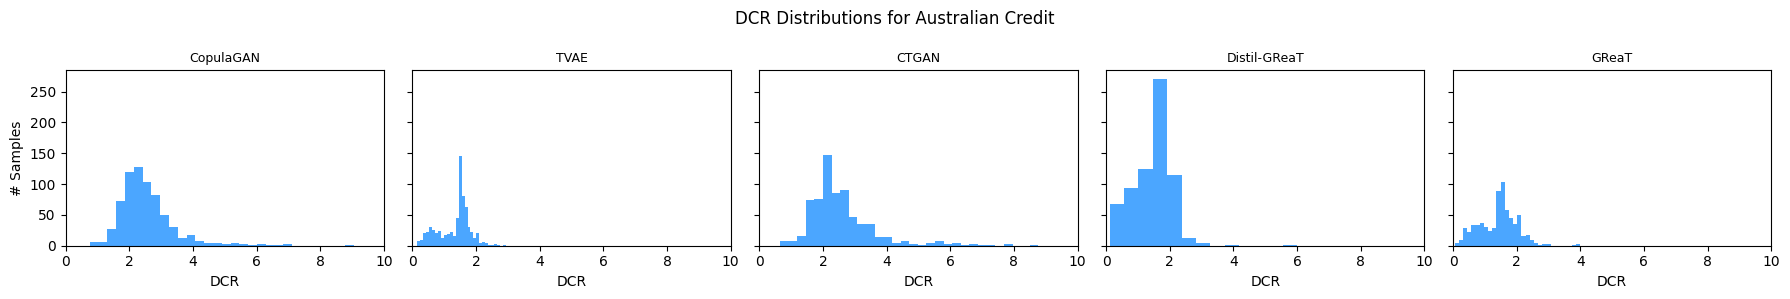

In [ ]:
dcr_results = {
    "CopulaGAN": compute_dcr(X_australian, X_australian_CopulaGAN),
    "TVAE": compute_dcr(X_australian, X_australian_TVAE),
    "CTGAN": compute_dcr(X_australian, X_australian_CTGAN),
    "Distil-GReaT": compute_dcr(X_australian, X_australian_distil_GReaT),
    "GReaT": compute_dcr(X_australian, X_australian_GReaT),
}

fig, axes = plt.subplots(1, len(dcr_results), figsize=(18, 3), sharey=True)
fig.suptitle(f"DCR Distributions for Australian Credit", fontsize=12)

for ax, (model_name, dcr_values) in zip(axes, dcr_results.items()):
    ax.hist(dcr_values, bins=30, color="dodgerblue", alpha=0.8)
    ax.set_title(model_name, fontsize=9)
    ax.set_xlabel("DCR")
    if ax == axes[0]:
        ax.set_ylabel("# Samples")
    ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

For the German Credit dataset, TVAE—despite achieving the best predictive performance overall—shows the lowest DCR values, meaning that many of its synthetic records are very close to the original ones. In contrast, Distil-GReaT and GReaT tend to generate samples that maintain a greater distance from the real data, suggesting higher variability.

For the Australian Credit dataset, a similar trend can be observed: TVAE again produces records closer to the originals, while CopulaGAN and CTGAN generate samples with larger DCR distributions, indicating higher diversity. However, in this case, the GReaT models do not perform as well, as their distributions remain closer to the original records.

CTGAN, which generally shows poor predictive accuracy, produces synthetic data that is more distant from the real records. This larger distance might directly contribute to its weaker predictive performance. Conversely, TVAE shows the opposite behavior: its stronger predictive accuracy is associated with lower distances to the original data, suggesting that its synthetic records mimic the original ones more closely. A similar relationship can be seen for the GReaT models, where better predictive performance corresponds to reduced DCR values.

This inverse relationship between DCR and accuracy highlights a possible trade-off between closeness to the original distribution (favoring predictive performance) and diversity of the synthetic data (favoring privacy and variability).

## 6 Conclusion

In summary, among the evaluated models, TVAE emerges as the best performer in terms of predictive accuracy, although its results in the discriminator and DCR analyses indicate weaknesses in terms of privacy and diversity. On the other hand, GReaT and Distil-GReaT, while slightly behind in accuracy, clearly outperform the other models in terms of discriminator resistance and DCR values, highlighting their strength in generating more diverse and less easily distinguishable synthetic data.

The main drawback of the GReaT family lies in their training time, which, as discussed in previous notebooks, is significantly higher than that of the other generative models and represents the main reason why many experiments were limited to partial training.

Overall, the key trade-off is between efficiency—high accuracy but lower privacy (as in TVAE)—and robustness with respect to diversity and indistinguishability (as in GReaT), at the cost of much longer training times.